In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("unsdsn/world-happiness")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'world-happiness' dataset.
Path to dataset files: /kaggle/input/world-happiness


In [8]:
df = pd.read_csv(path + "/2019.csv")
df.head()
display(df.info())
display(df.describe())
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


None

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


,0
Overall rank,0
Country or region,0
Score,0
GDP per capita,0
Social support,0
Healthy life expectancy,0
Freedom to make life choices,0
Generosity,0
Perceptions of corruption,0


#**Data Preprocessing:**

In [10]:
df['Country or region'].str.lower().str.strip().str.replace(' ','')
df.head()
df['Country or region'].unique()

array(['Finland', 'Denmark', 'Norway', 'Iceland', 'Netherlands',
       'Switzerland', 'Sweden', 'New Zealand', 'Canada', 'Austria',
       'Australia', 'Costa Rica', 'Israel', 'Luxembourg',
       'United Kingdom', 'Ireland', 'Germany', 'Belgium', 'United States',
       'Czech Republic', 'United Arab Emirates', 'Malta', 'Mexico',
       'France', 'Taiwan', 'Chile', 'Guatemala', 'Saudi Arabia', 'Qatar',
       'Spain', 'Panama', 'Brazil', 'Uruguay', 'Singapore', 'El Salvador',
       'Italy', 'Bahrain', 'Slovakia', 'Trinidad & Tobago', 'Poland',
       'Uzbekistan', 'Lithuania', 'Colombia', 'Slovenia', 'Nicaragua',
       'Kosovo', 'Argentina', 'Romania', 'Cyprus', 'Ecuador', 'Kuwait',
       'Thailand', 'Latvia', 'South Korea', 'Estonia', 'Jamaica',
       'Mauritius', 'Japan', 'Honduras', 'Kazakhstan', 'Bolivia',
       'Hungary', 'Paraguay', 'Northern Cyprus', 'Peru', 'Portugal',
       'Pakistan', 'Russia', 'Philippines', 'Serbia', 'Moldova', 'Libya',
       'Montenegro', 'Tajikis

#**Social Support and Happiness:**

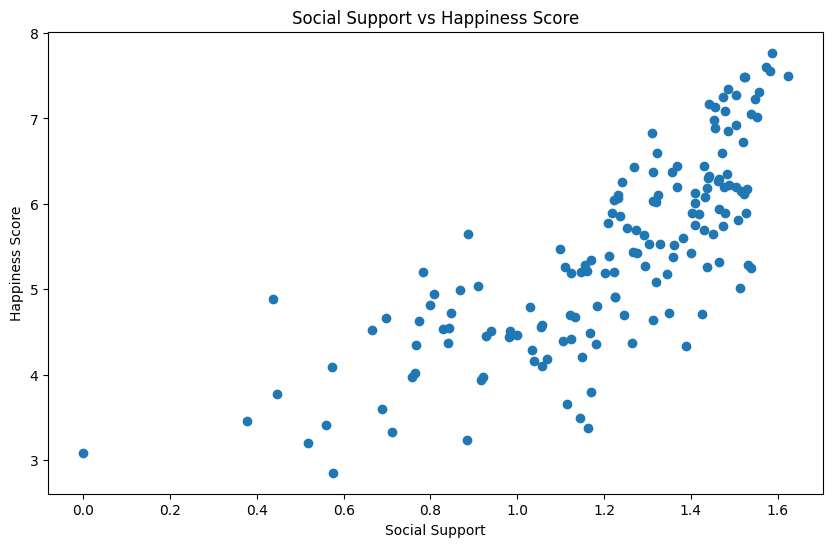

In [11]:
plt.figure(figsize=(10,6))

plt.scatter(df['Social support'],df['Score'])
plt.xlabel('Social Support')
plt.ylabel('Happiness Score')
plt.title('Social Support vs Happiness Score')
plt.show()

#**Regional Comparisons of GDP and Health:**

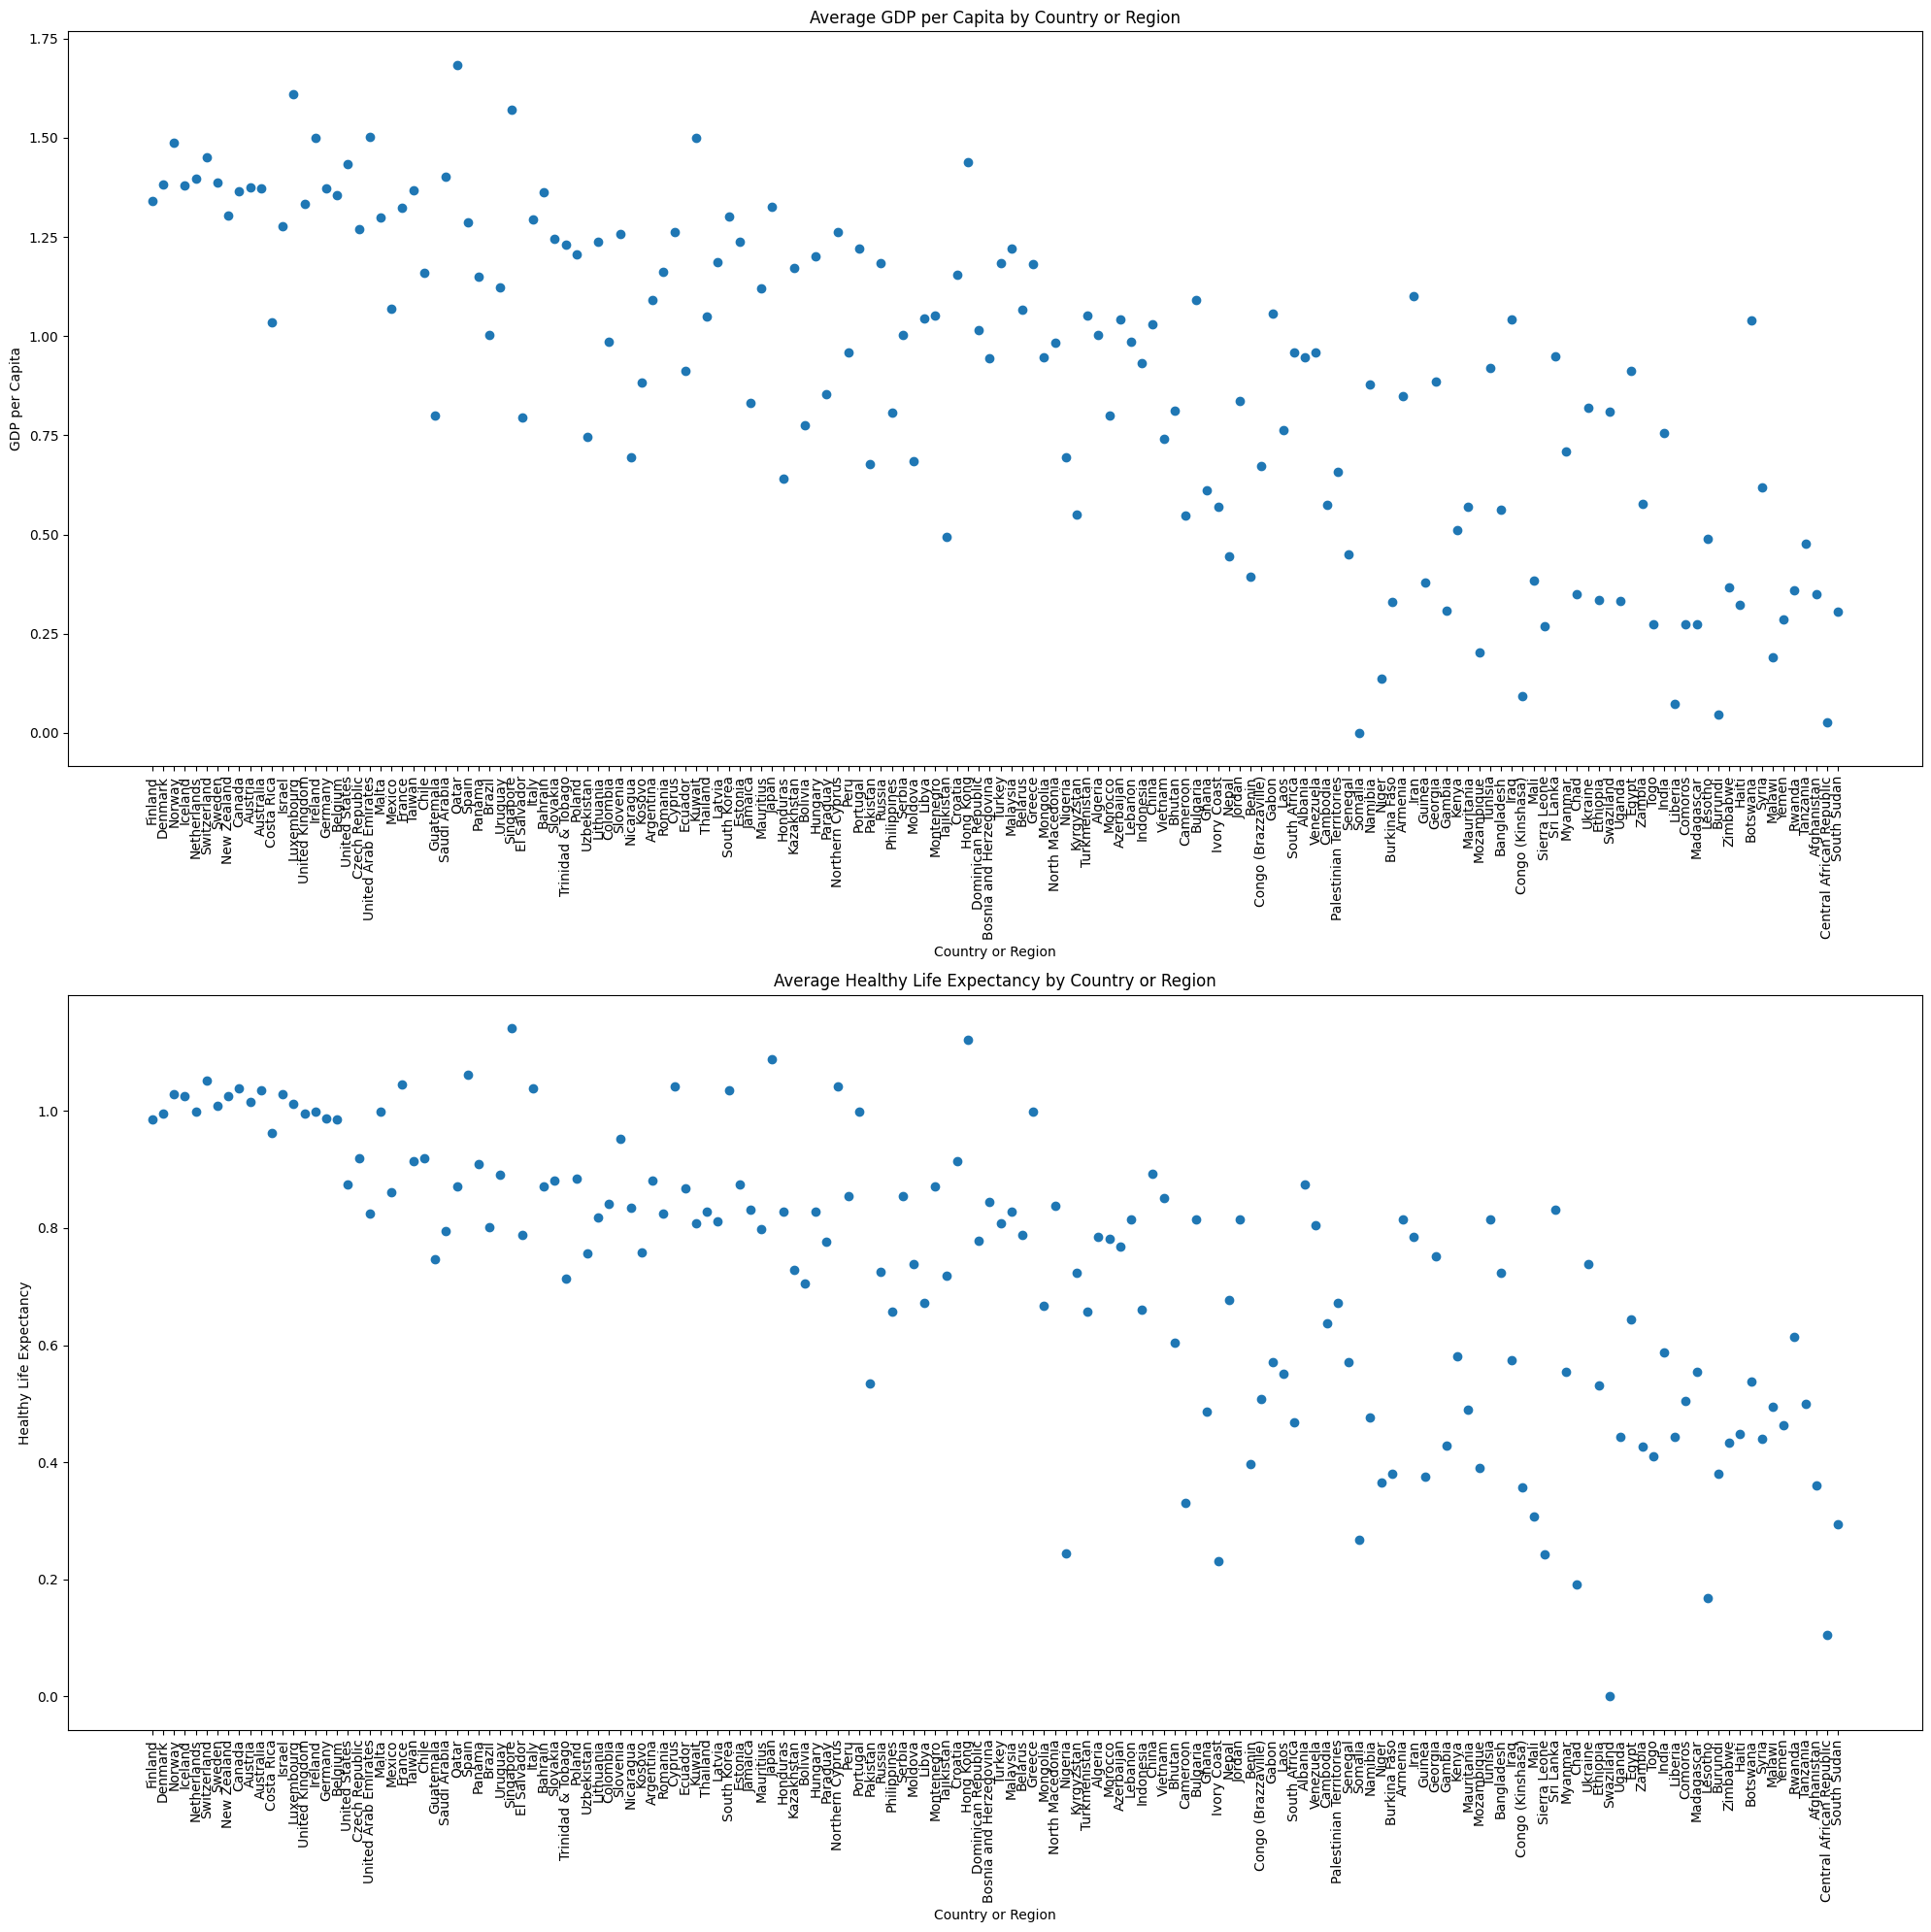

In [31]:
fig, (a1,a2) = plt.subplots(2,1,figsize=(20,20))
a1.scatter(df['Country or region'] ,df['GDP per capita'])
a1.set_title('Average GDP per Capita by Country or Region')
a1.set_xlabel('Country or Region')
a1.tick_params(axis='x', rotation=90)
a1.set_ylabel('GDP per Capita')


a2.scatter(df['Country or region'] , df['Healthy life expectancy'])
a2.set_title('Average Healthy Life Expectancy by Country or Region')
a2.set_xlabel('Country or Region')
a2.set_ylabel('Healthy Life Expectancy')
a2.tick_params(axis='x', rotation=90)
plt.tight_layout()

plt.show()
#

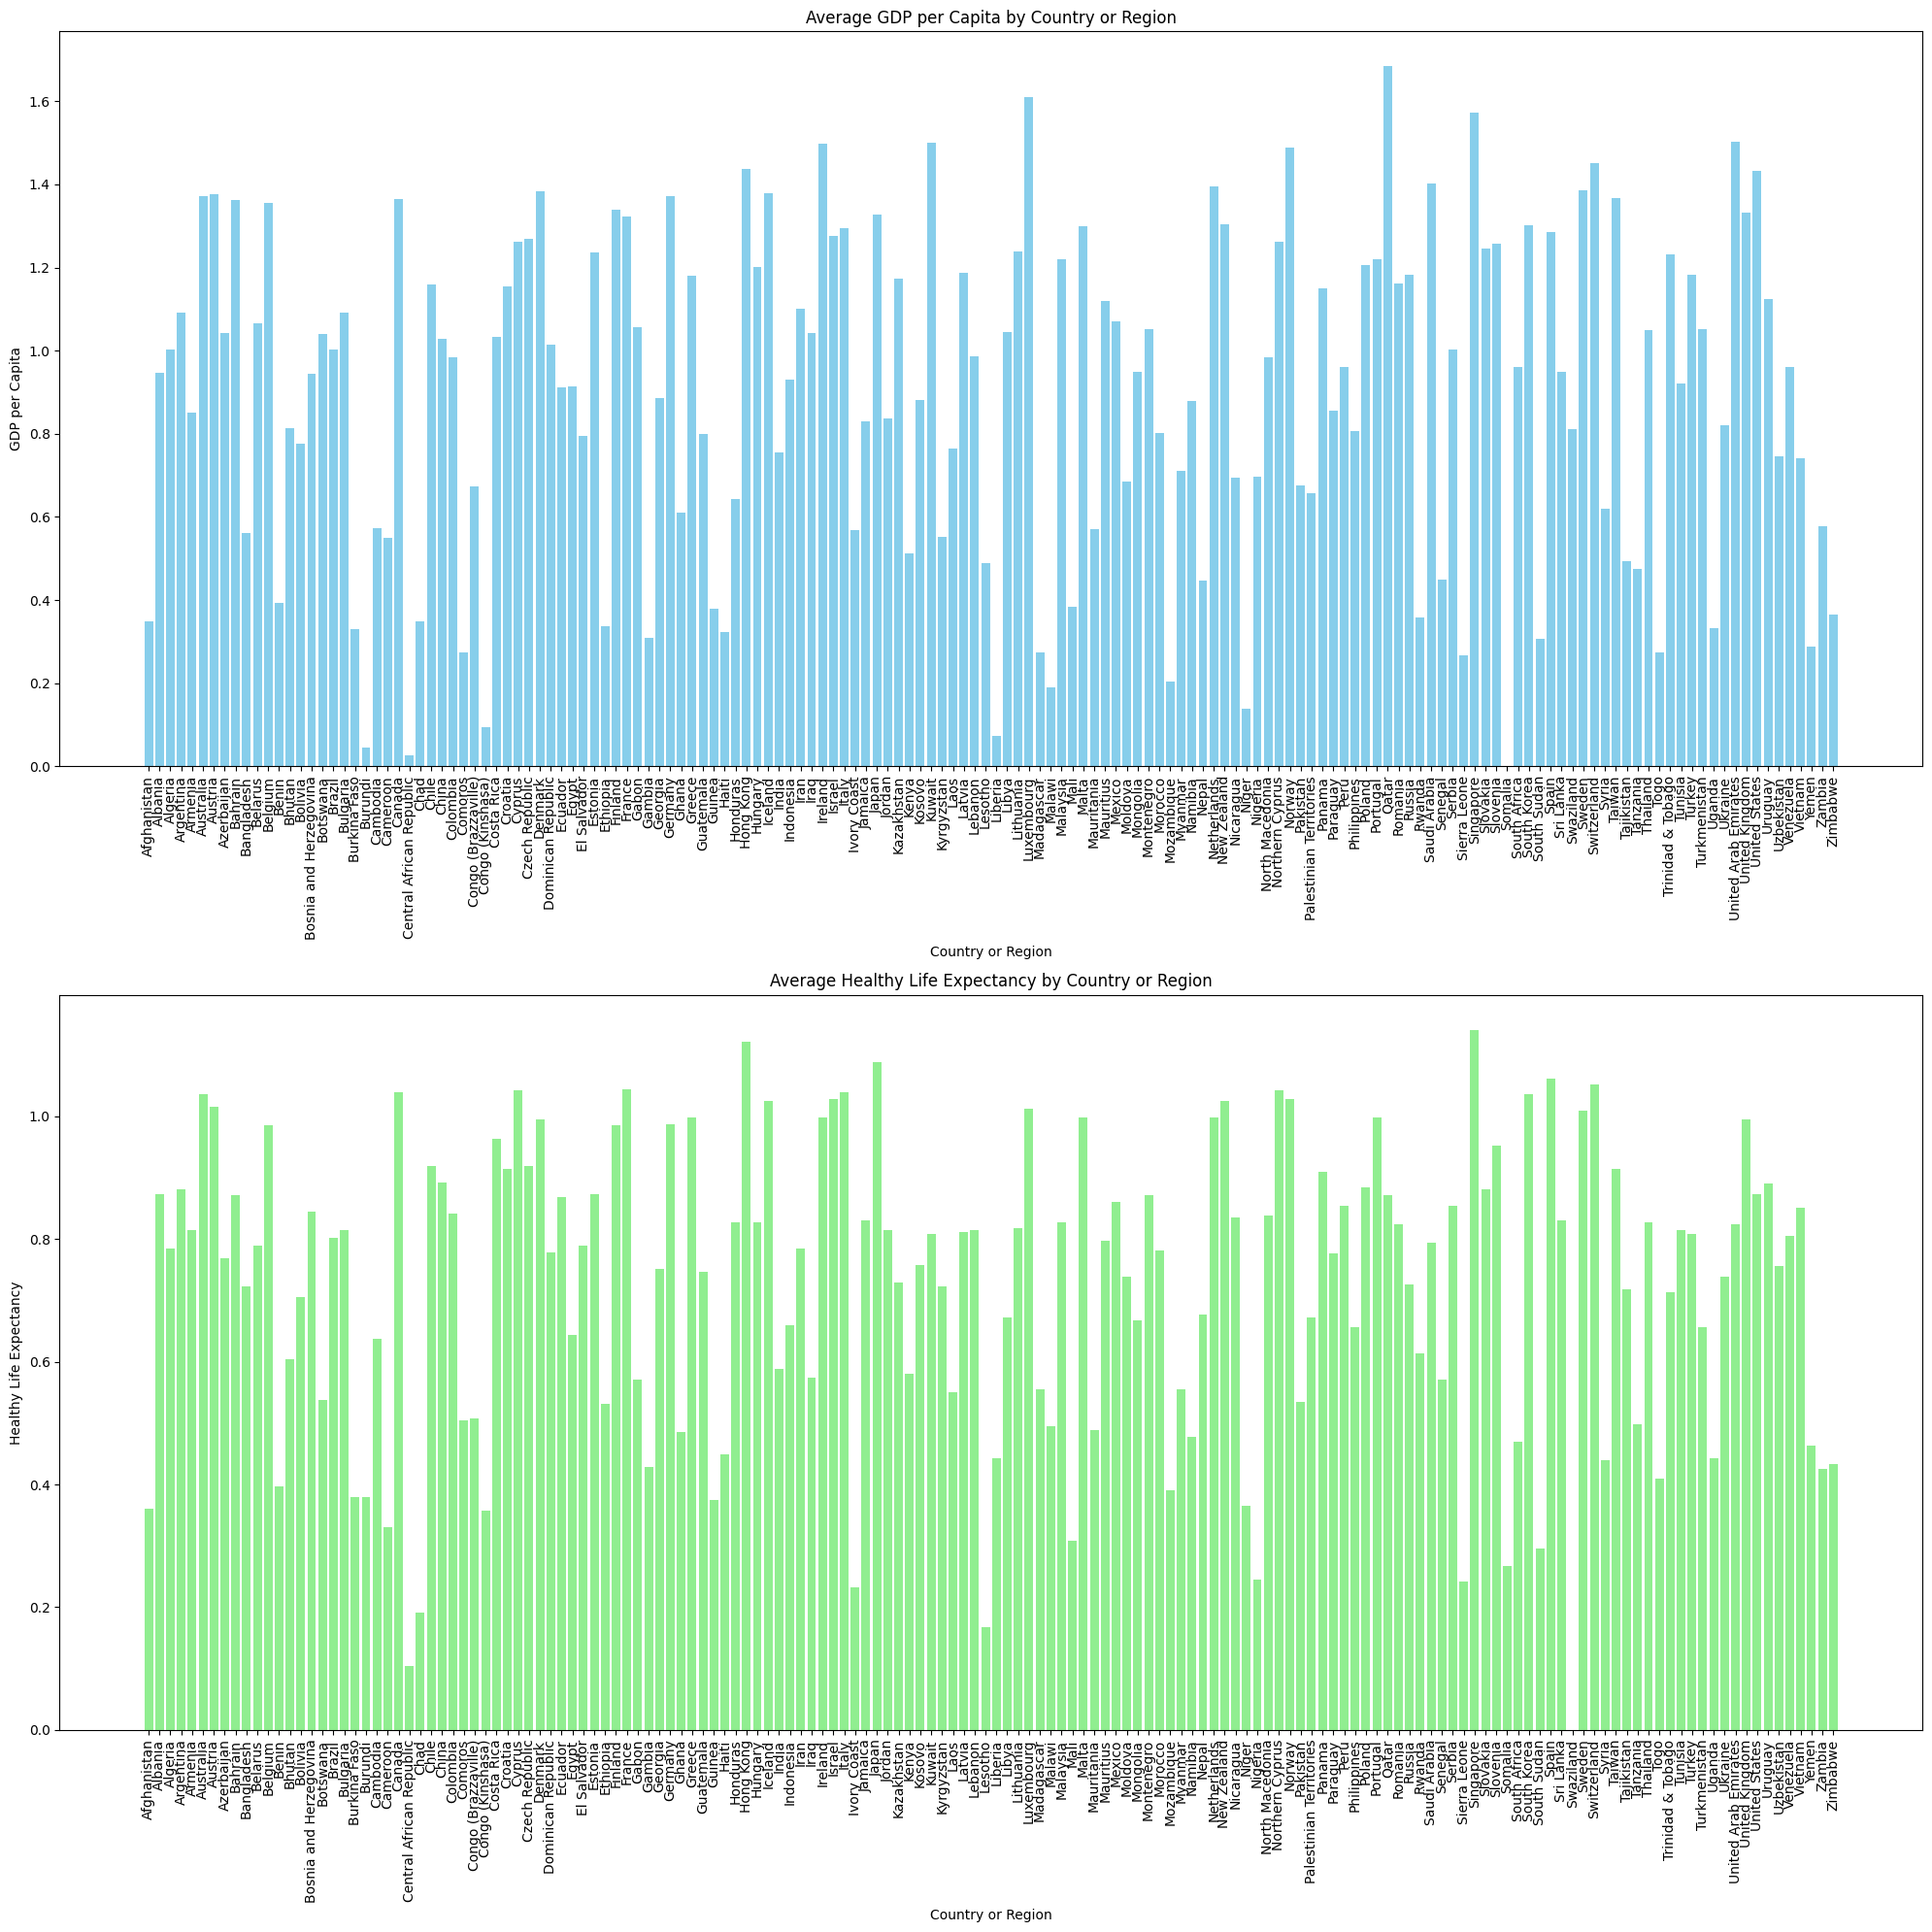

In [19]:
import matplotlib.pyplot as plt

# Group by country or region: average GDP per capita and Healthy life expectancy
region_stats = (
    df.groupby('Country or region')[['GDP per capita', 'Healthy life expectancy']]
      .mean()
      .reset_index()
)

# Create subplots
fig, (a1, a2) = plt.subplots(2, 1, figsize=(20, 20))

# First subplot: GDP per capita by country or region
a1.bar(region_stats['Country or region'], region_stats['GDP per capita'], color='skyblue')
a1.set_title('Average GDP per Capita by Country or Region')
a1.set_xlabel('Country or Region')
a1.set_ylabel('GDP per Capita')
a1.tick_params(axis='x', rotation=90)

# Second subplot: Healthy life expectancy by country or region
a2.bar(region_stats['Country or region'], region_stats['Healthy life expectancy'], color='lightgreen')
a2.set_title('Average Healthy Life Expectancy by Country or Region')
a2.set_xlabel('Country or Region')
a2.set_ylabel('Healthy Life Expectancy')
a2.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

##Use a bar plot for 'GDP per Capita' and a line plot for 'Healthy Life Expectancy' on the same axes to observe how economic strength relates to health outcomes in different regions.

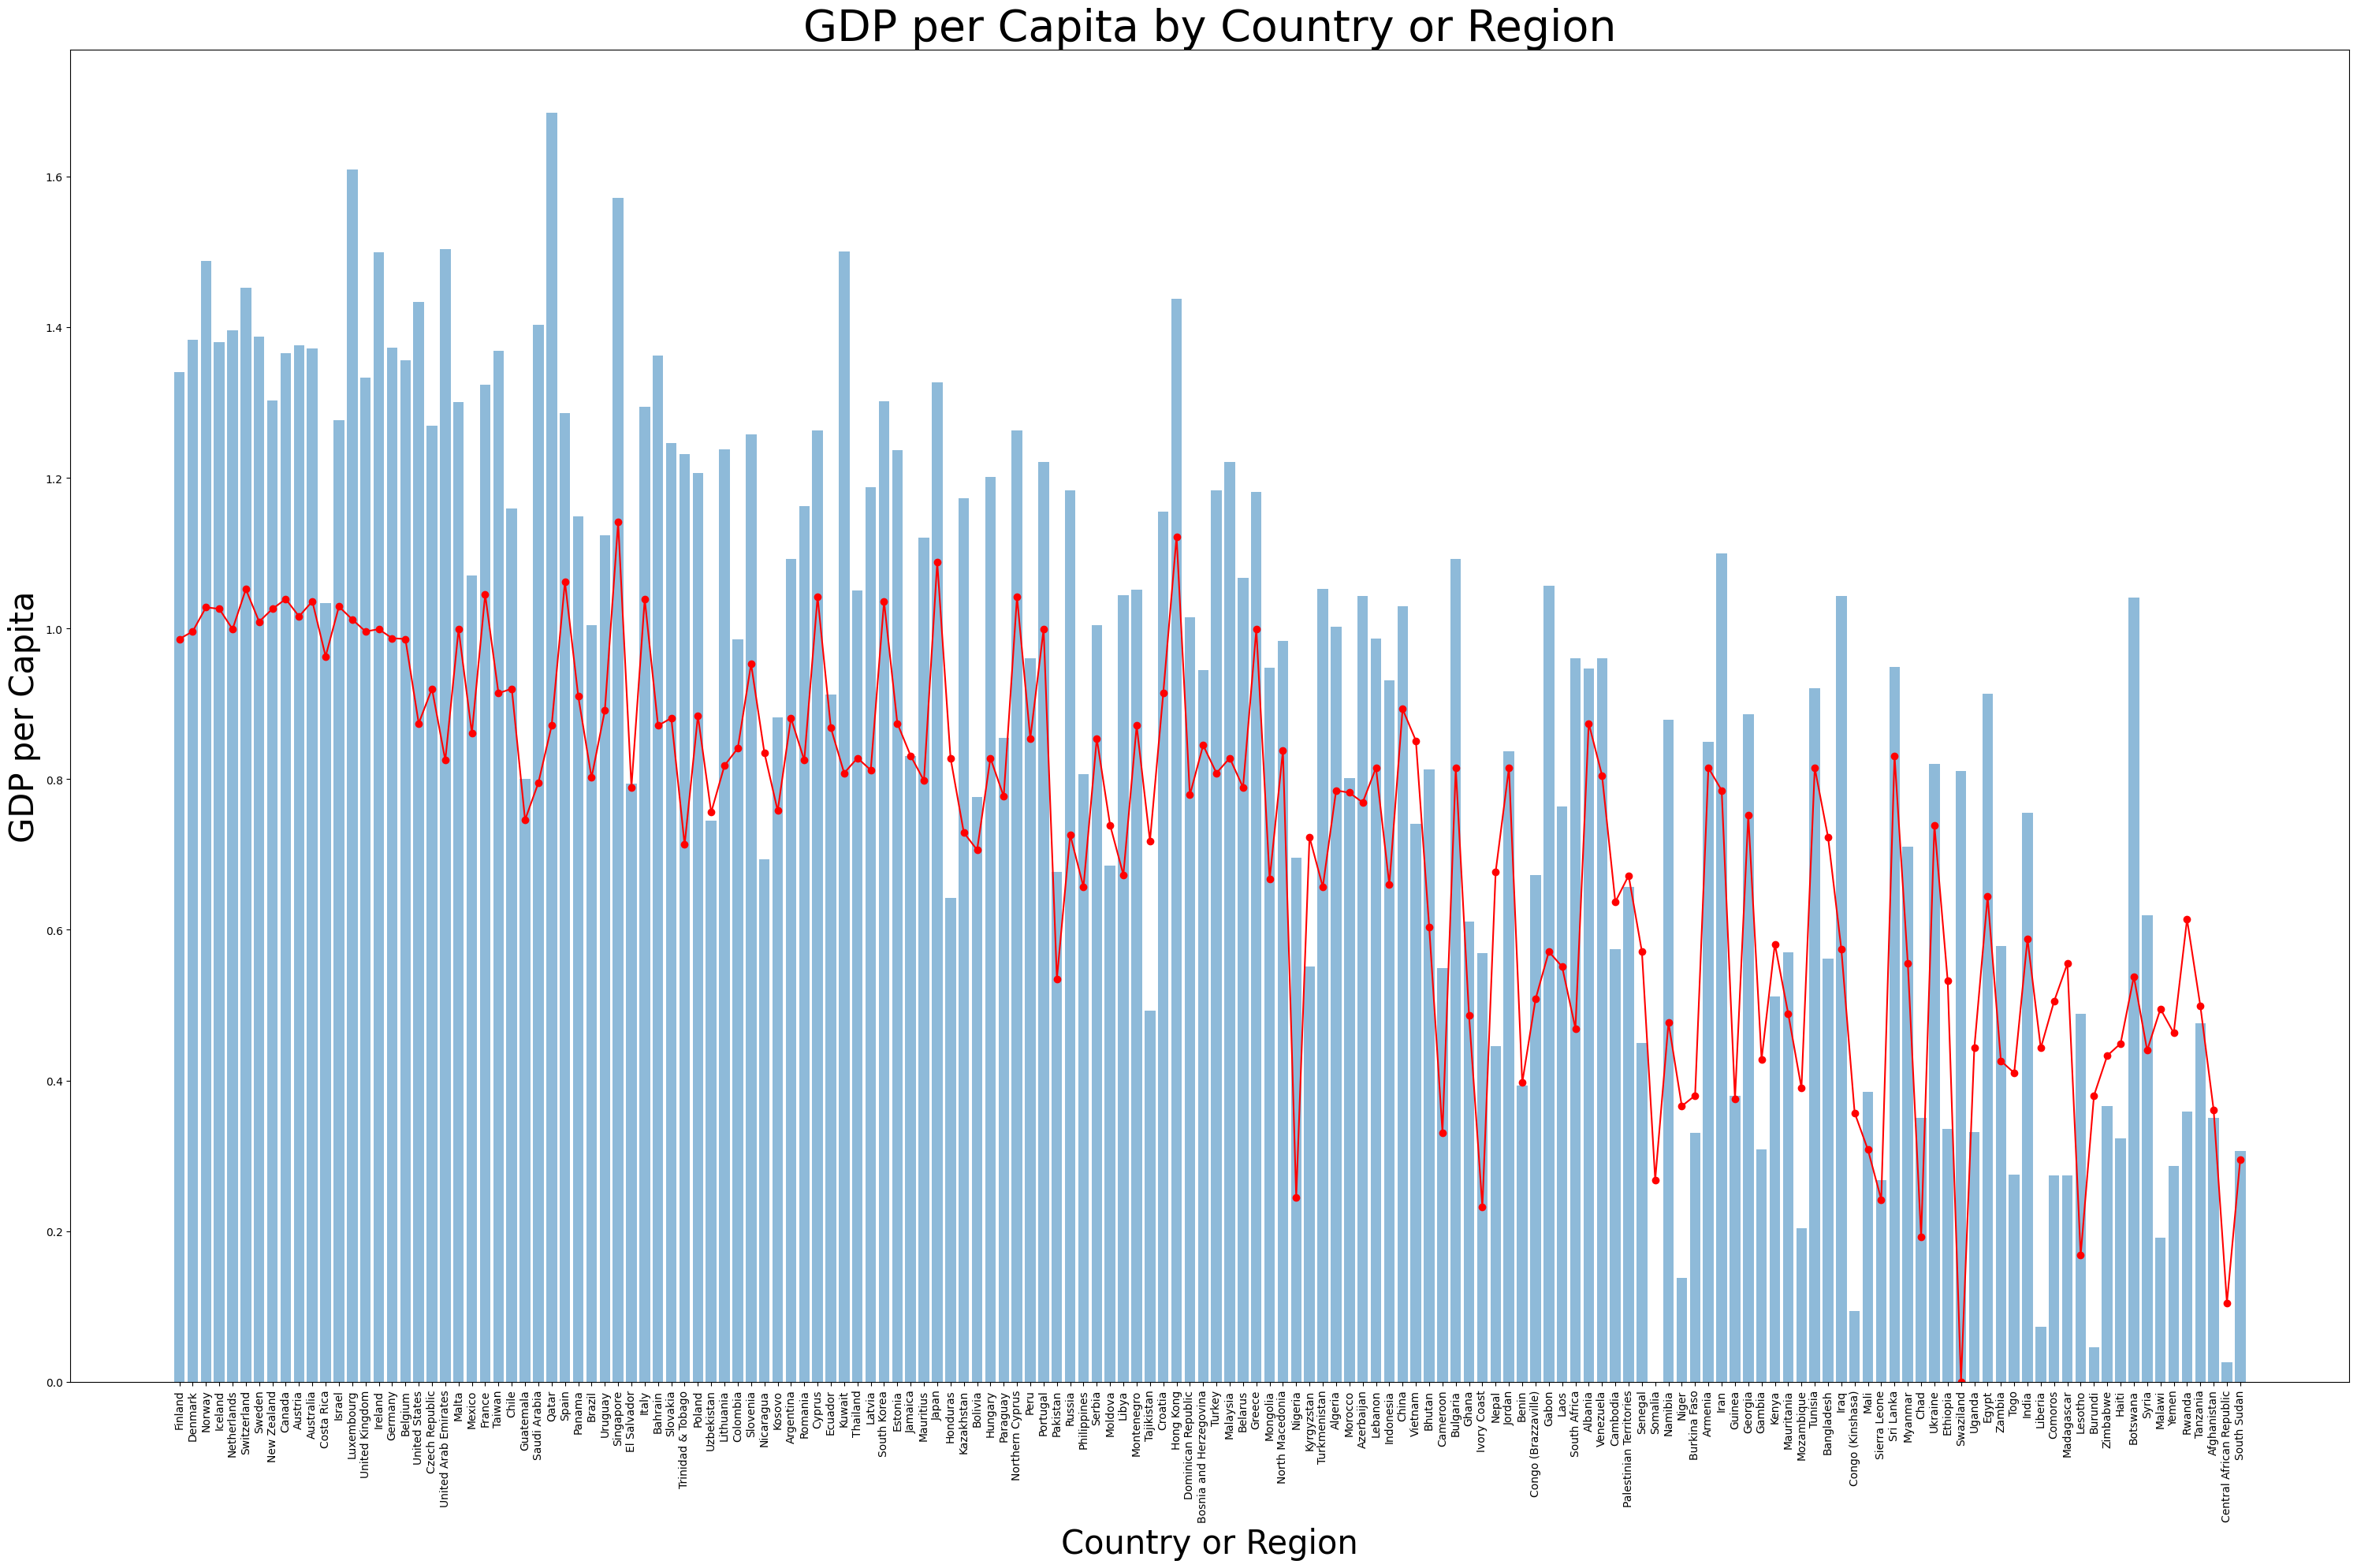

In [43]:
plt.figure(figsize=(30, 20))
plt.bar(df['Country or region'], df['GDP per capita'], alpha=0.5)
plt.plot(df['Country or region'], df['Healthy life expectancy'], marker='o', linestyle='-', color='red')
plt.xlabel('Country or Region', fontsize=30)
plt.ylabel('GDP per Capita', fontsize=30)
plt.title('GDP per Capita by Country or Region', fontsize=40)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()